# Nedbank Transaction Volume Forecasting
## Portfolio Exploration Notebook

---

### Problem Description

Given the historical banking behaviour of **11,944 customers** (transactions, financials, demographics),  
the goal is to **predict the total number of bank transactions each customer will make  
in the next 3-month window (November 2015 – January 2016)**.

| Item | Detail |
|---|---|
| **Target** | `next_3m_txn_count` — non-negative integer |
| **Metric** | RMSLE (Root Mean Squared Logarithmic Error) |
| **Train set** | 8,360 customers |
| **Test set** | 3,584 customers |
| **Raw data** | 18M transaction rows · 372K financial snapshots · 11,944 demographic profiles |

> This notebook is **read-only analysis**. No training is performed here.

---
## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
ACCENT = '#2E86AB'
WARN   = '#E84855'

# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_FEATURES  = '../data/processed/train_features.parquet'
OOF_PATH        = '../data/processed/oof_predictions.csv'
IMPORTANCE_PATH = '../data/processed/feature_importance.csv'

print('Environment ready.')

Environment ready.


---
## 2. Load Data

In [2]:
# ── Processed features ─────────────────────────────────────────────────────
train = pd.read_parquet(TRAIN_FEATURES)
if 'UniqueID' in train.columns:
    train = train.set_index('UniqueID')

y = train['next_3m_txn_count'].astype(float)
X = train.drop(columns=['next_3m_txn_count'], errors='ignore')

# ── OOF predictions ────────────────────────────────────────────────────────
oof = pd.read_csv(OOF_PATH)
y_true = oof['next_3m_txn_count_true'].values.astype(float)
y_pred = oof['next_3m_txn_count_pred'].values.astype(float)

# ── Feature importance ─────────────────────────────────────────────────────
imp = pd.read_csv(IMPORTANCE_PATH)

print(f'Train features : {X.shape[0]:,} rows × {X.shape[1]} columns')
print(f'OOF predictions: {len(oof):,} rows')
print(f'Feature importance: {len(imp)} features')
print()
print(y.describe().to_frame('next_3m_txn_count').T)

Train features : 8,360 rows × 158 columns
OOF predictions: 8,360 rows
Feature importance: 158 features

                    count        mean         std  min   25%    50%    75%  \
next_3m_txn_count  8360.0  144.969019  152.156725  1.0  35.0  102.0  201.0   

                      max  
next_3m_txn_count  1794.0  


---
## 3. Target Analysis

The target `next_3m_txn_count` is a **count variable** — right-skewed, non-negative, with no zeros.
Training directly on `log1p(y)` aligns with the RMSLE objective.

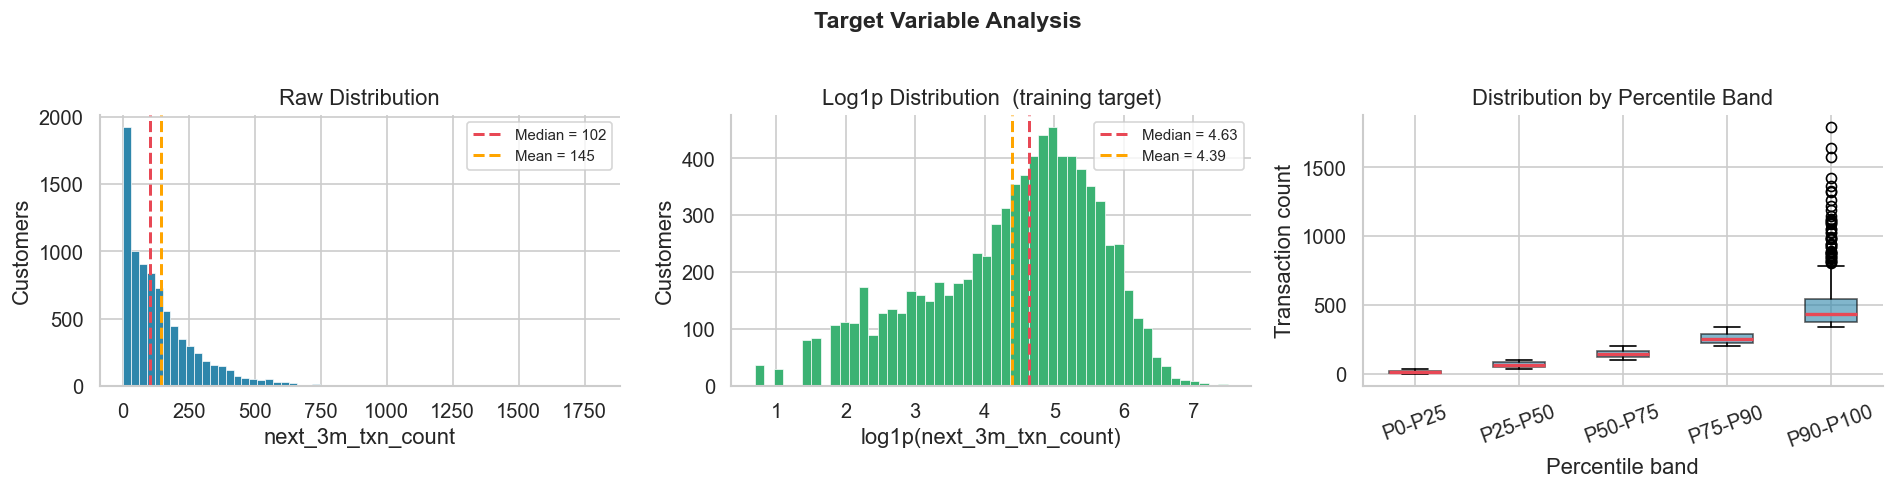

Raw  — skew: 2.407   kurtosis: 10.589
Log1p— skew: -0.618   kurtosis: -0.248

→ Log1p transform reduces skewness from ~2.4 → ~-0.6, making the target
  approximately symmetric and well-suited for regression-based models.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Raw distribution ───────────────────────────────────────────────────────
ax = axes[0]
ax.hist(y, bins=60, color=ACCENT, edgecolor='white', linewidth=0.4)
ax.axvline(y.median(), color=WARN, lw=1.8, ls='--', label=f'Median = {y.median():.0f}')
ax.axvline(y.mean(),   color='orange', lw=1.8, ls='--', label=f'Mean = {y.mean():.0f}')
ax.set_xlabel('next_3m_txn_count')
ax.set_ylabel('Customers')
ax.set_title('Raw Distribution')
ax.legend(fontsize=9)

# ── log1p distribution ─────────────────────────────────────────────────────
ax = axes[1]
y_log = np.log1p(y)
ax.hist(y_log, bins=50, color='#3BB273', edgecolor='white', linewidth=0.4)
ax.axvline(y_log.median(), color=WARN,    lw=1.8, ls='--', label=f'Median = {y_log.median():.2f}')
ax.axvline(y_log.mean(),   color='orange',lw=1.8, ls='--', label=f'Mean = {y_log.mean():.2f}')
ax.set_xlabel('log1p(next_3m_txn_count)')
ax.set_ylabel('Customers')
ax.set_title('Log1p Distribution  (training target)')
ax.legend(fontsize=9)

# ── Box plot by percentile band ────────────────────────────────────────────
ax = axes[2]
labels = ['P0-P25', 'P25-P50', 'P50-P75', 'P75-P90', 'P90-P100']
quantiles = np.quantile(y, [0, 0.25, 0.50, 0.75, 0.90, 1.0])
groups = []
for i in range(len(quantiles) - 1):
    mask = (y >= quantiles[i]) & (y <= quantiles[i+1])
    groups.append(y[mask].values)
bp = ax.boxplot(groups, labels=labels, patch_artist=True,
                medianprops=dict(color=WARN, linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(ACCENT)
    patch.set_alpha(0.6)
ax.set_xlabel('Percentile band')
ax.set_ylabel('Transaction count')
ax.set_title('Distribution by Percentile Band')
ax.tick_params(axis='x', rotation=20)

fig.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Skewness summary ───────────────────────────────────────────────────────
from scipy.stats import skew, kurtosis
print(f'Raw  — skew: {skew(y):.3f}   kurtosis: {kurtosis(y):.3f}')
print(f'Log1p— skew: {skew(y_log):.3f}   kurtosis: {kurtosis(y_log):.3f}')
print()
print('→ Log1p transform reduces skewness from ~2.4 → ~-0.6, making the target')
print('  approximately symmetric and well-suited for regression-based models.')

---
## 4. Feature Overview

Features are engineered from three sources:

| Source | Type | Key features |
|---|---|---|
| **Transactions** | Time-window aggregates, recency, frequency, behaviour, trend, type-level | `txn_count_30d`, `txn_per_month`, `last3_count`, `nov_jan_txn_frac` |
| **Financials** | Balance stats, account mix, trend | `NetInterestIncome_mean`, `n_accounts`, `has_mortgage` |
| **Demographics** | Age, income, occupation, categorical encodes | `age`, `log1p_annual_income`, `OccupationCategory_enc` |

In [4]:
# ── Key feature summary stats ──────────────────────────────────────────────
key_features = [
    'txn_count_30d', 'txn_count_90d', 'txn_count_180d',
    'txn_per_month', 'last3_count', 'prior3_count',
    'days_since_last_txn', 'total_txn_count',
    'nov_jan_txn_count_hist', 'nov_jan_txn_frac',
    'debit_fraction', 'amount_volatility',
    'n_accounts', 'NetInterestIncome_mean',
    'age', 'log1p_annual_income',
]
present = [f for f in key_features if f in X.columns]
stats = X[present].describe().T[['mean','std','min','50%','max']]
stats.columns = ['mean','std','min','median','max']
stats = stats.round(2)
print('Key Feature Summary Statistics')
print('=' * 70)
print(stats.to_string())

Key Feature Summary Statistics
                           mean      std      min   median       max
txn_count_30d             45.79    46.88     0.00    32.00    231.00
txn_count_90d            136.26   135.74     2.00    96.00    669.57
txn_count_180d           269.90   266.40     3.00   194.00   1306.57
txn_per_month             44.57    41.08     1.30    33.34    197.43
last3_count              136.26   135.74     2.00    96.00    669.57
prior3_count             133.46   133.16     0.00    96.00    647.57
days_since_last_txn        1.62     5.13     0.00     0.00     36.00
total_txn_count         1486.40  1429.29     5.00  1097.00   6785.40
nov_jan_txn_count_hist   307.32   301.43     0.00   226.00   1423.57
nov_jan_txn_frac           0.19     0.06     0.00     0.20      0.33
debit_fraction             0.73     0.18     0.03     0.77      0.96
amount_volatility        619.53  1508.43     1.02   189.34  11346.22
n_accounts                 1.60     1.01     1.00     1.00      6.00
Net

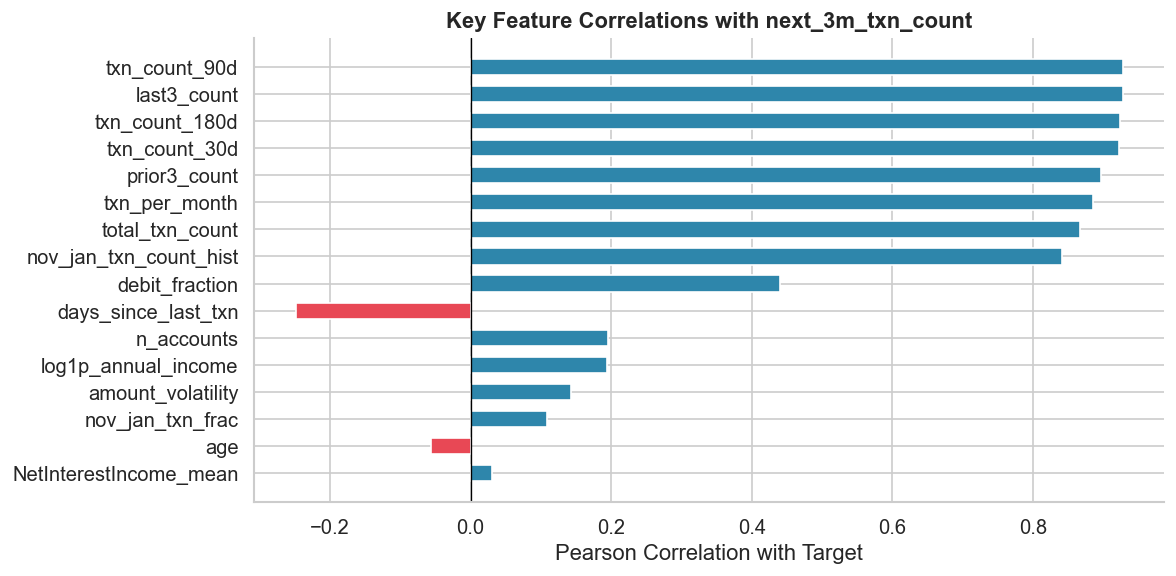

Top positive correlations (more activity → more future transactions):
txn_count_90d     0.928203
last3_count       0.928203
txn_count_180d    0.923280
txn_count_30d     0.922389
prior3_count      0.896899

Top negative correlations (recency: longer since last txn → fewer future):
days_since_last_txn   -0.248799
age                   -0.056735


In [5]:
# ── Correlation of key features with target ────────────────────────────────
corr_with_target = (
    X[present]
    .assign(target=y)
    .corr()['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT if v >= 0 else WARN for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
        color=colors[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Key Feature Correlations with next_3m_txn_count', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top positive correlations (more activity → more future transactions):')
print(corr_with_target[corr_with_target > 0].head(5).to_string())
print()
print('Top negative correlations (recency: longer since last txn → fewer future):')
print(corr_with_target[corr_with_target < 0].head(3).to_string())

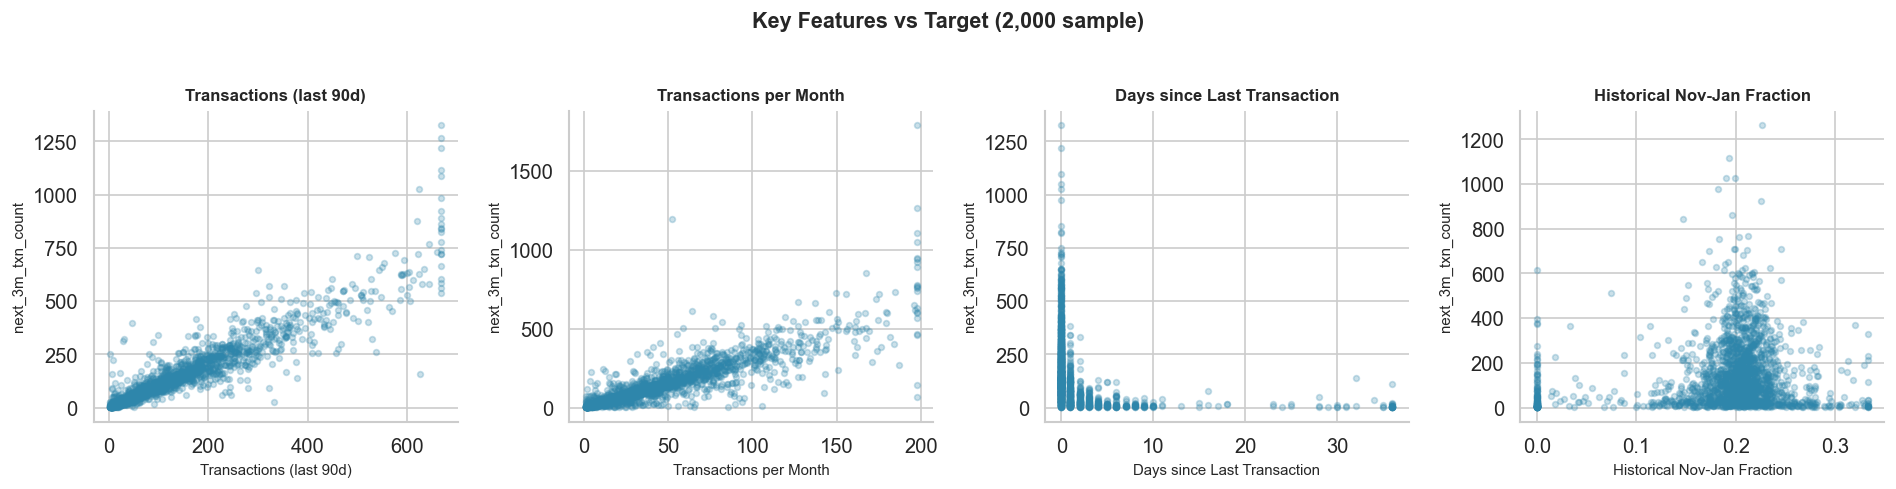

In [6]:
# ── Scatter: key drivers vs target ─────────────────────────────────────────
scatter_feats = [
    ('txn_count_90d',       'Transactions (last 90d)'),
    ('txn_per_month',       'Transactions per Month'),
    ('days_since_last_txn', 'Days since Last Transaction'),
    ('nov_jan_txn_frac',    'Historical Nov-Jan Fraction'),
]
scatter_feats = [(f, l) for f, l in scatter_feats if f in X.columns]

fig, axes = plt.subplots(1, len(scatter_feats), figsize=(16, 4))
for ax, (feat, label) in zip(axes, scatter_feats):
    sample_idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
    ax.scatter(
        X[feat].iloc[sample_idx],
        y.iloc[sample_idx],
        alpha=0.25, s=12, color=ACCENT
    )
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('next_3m_txn_count', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')

fig.suptitle('Key Features vs Target (2,000 sample)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Feature Importance

Importances are averaged over 5 cross-validation folds from the LightGBM ensemble.

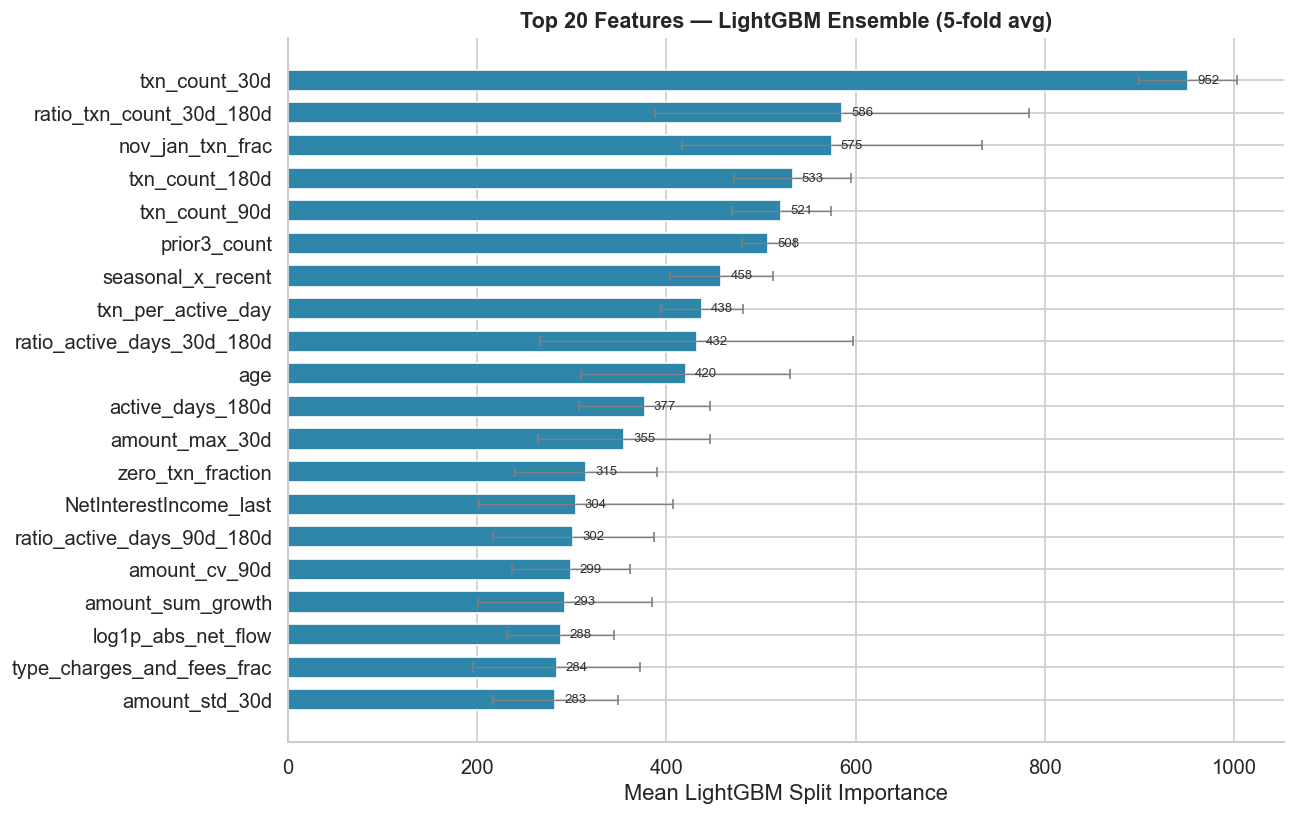

Interpretation:
  • Recent transaction counts (30d/90d) dominate — behavioural momentum
    is the strongest predictor of future activity.
  • Recency (days_since_last_txn) signals customer engagement level.
  • Historical Nov-Jan seasonality directly proxies the prediction window.
  • Financial features (NetInterestIncome) add complementary signal
    about account activity levels.


In [7]:
top20 = imp.nlargest(20, 'importance_mean').sort_values('importance_mean')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top20['feature'], top20['importance_mean'],
    xerr=top20.get('importance_std', pd.Series(0, index=top20.index)),
    color=ACCENT, edgecolor='white', height=0.65,
    error_kw=dict(ecolor='gray', capsize=3, linewidth=0.8)
)
ax.set_xlabel('Mean LightGBM Split Importance')
ax.set_title('Top 20 Features — LightGBM Ensemble (5-fold avg)', fontweight='bold', fontsize=13)

# Annotate bars
for bar, val in zip(bars, top20['importance_mean']):
    ax.text(val + top20['importance_mean'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='left', fontsize=8, color='#333333')

plt.tight_layout()
plt.show()

print('Interpretation:')
print('  • Recent transaction counts (30d/90d) dominate — behavioural momentum')
print('    is the strongest predictor of future activity.')
print('  • Recency (days_since_last_txn) signals customer engagement level.')
print('  • Historical Nov-Jan seasonality directly proxies the prediction window.')
print('  • Financial features (NetInterestIncome) add complementary signal')
print('    about account activity levels.')

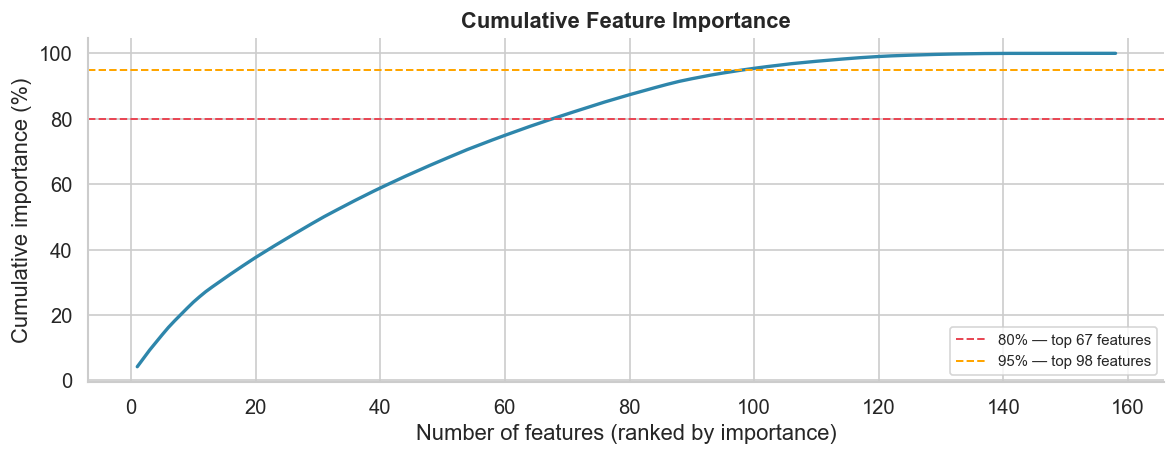

  67 features capture 80% of total split importance.
  98 features capture 95% of total split importance.
  Total features in model: 158


In [8]:
# ── Cumulative importance ──────────────────────────────────────────────────
imp_sorted = imp.sort_values('importance_mean', ascending=False).reset_index(drop=True)
total_imp  = imp_sorted['importance_mean'].sum()
imp_sorted['cumulative_pct'] = imp_sorted['importance_mean'].cumsum() / total_imp * 100

p80 = (imp_sorted['cumulative_pct'] <= 80).sum()
p95 = (imp_sorted['cumulative_pct'] <= 95).sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(imp_sorted) + 1), imp_sorted['cumulative_pct'],
        color=ACCENT, lw=2)
ax.axhline(80, color=WARN,    ls='--', lw=1.2, label=f'80% — top {p80} features')
ax.axhline(95, color='orange',ls='--', lw=1.2, label=f'95% — top {p95} features')
ax.set_xlabel('Number of features (ranked by importance)')
ax.set_ylabel('Cumulative importance (%)')
ax.set_title('Cumulative Feature Importance', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'  {p80} features capture 80% of total split importance.')
print(f'  {p95} features capture 95% of total split importance.')
print(f'  Total features in model: {len(imp_sorted)}')

---
## 6. Error Analysis

Out-of-fold predictions from 5-fold cross-validation give an unbiased view  
of model performance across all training customers.

In [9]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print('=' * 40)
print(f'  OOF RMSLE : {rmsle(y_true, y_pred):.6f}')
print(f'  OOF MAE   : {mae(y_true, y_pred):.2f} transactions')
print(f'  OOF MAPE  : {mape(y_true, y_pred):.2f}%')
print('=' * 40)

  OOF RMSLE : 0.383966
  OOF MAE   : 26.07 transactions
  OOF MAPE  : 29.60%


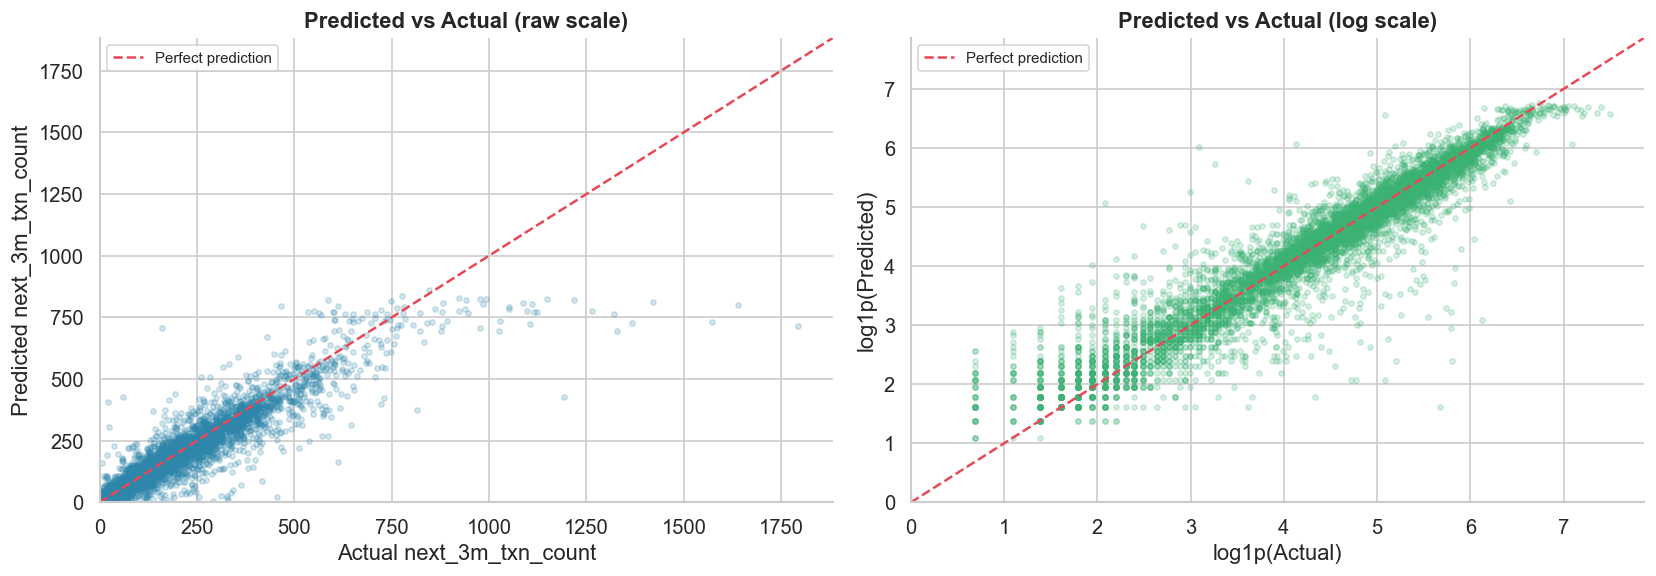

In [10]:
# ── Predicted vs Actual ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
ax = axes[0]
lim = max(y_true.max(), y_pred.max()) * 1.05
ax.scatter(y_true, y_pred, alpha=0.2, s=10, color=ACCENT)
ax.plot([0, lim], [0, lim], color=WARN, lw=1.5, ls='--', label='Perfect prediction')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('Actual next_3m_txn_count')
ax.set_ylabel('Predicted next_3m_txn_count')
ax.set_title('Predicted vs Actual (raw scale)', fontweight='bold')
ax.legend(fontsize=9)

# Log scale
ax = axes[1]
log_true = np.log1p(y_true)
log_pred = np.log1p(y_pred)
lim_log  = max(log_true.max(), log_pred.max()) * 1.05
ax.scatter(log_true, log_pred, alpha=0.2, s=10, color='#3BB273')
ax.plot([0, lim_log], [0, lim_log], color=WARN, lw=1.5, ls='--', label='Perfect prediction')
ax.set_xlim(0, lim_log)
ax.set_ylim(0, lim_log)
ax.set_xlabel('log1p(Actual)')
ax.set_ylabel('log1p(Predicted)')
ax.set_title('Predicted vs Actual (log scale)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

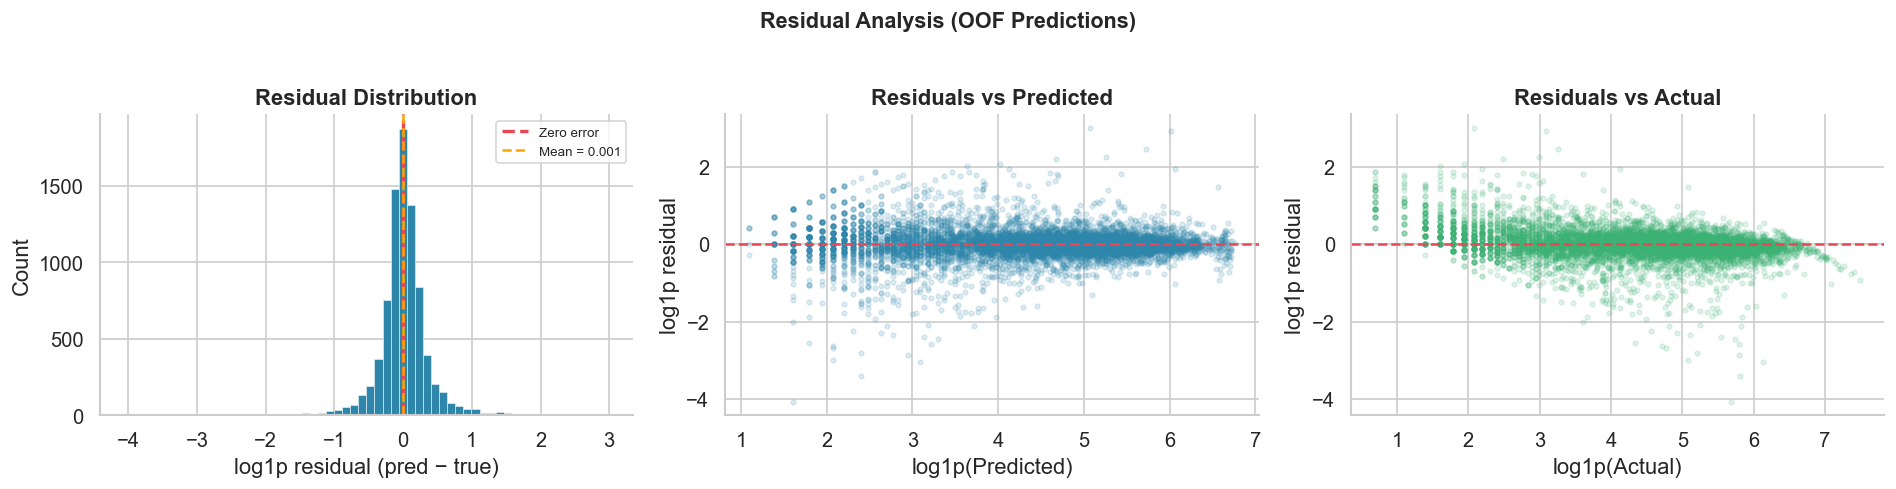

Residual stats:
  Mean  : 0.0005  (bias — negative = under-prediction)
  Std   : 0.3840
  Skew  : -0.4462
  Over-predicted  : 47.9% of customers
  Under-predicted : 48.8% of customers


In [11]:
# ── Residual analysis ──────────────────────────────────────────────────────
log_residuals = np.log1p(y_pred) - np.log1p(y_true)  # signed log residuals

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residual histogram
ax = axes[0]
ax.hist(log_residuals, bins=60, color=ACCENT, edgecolor='white', linewidth=0.3)
ax.axvline(0,                     color=WARN,    lw=2,   ls='--', label='Zero error')
ax.axvline(log_residuals.mean(),  color='orange',lw=1.5, ls='--',
           label=f'Mean = {log_residuals.mean():.3f}')
ax.set_xlabel('log1p residual (pred − true)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontweight='bold')
ax.legend(fontsize=8)

# Residual vs predicted
ax = axes[1]
ax.scatter(np.log1p(y_pred), log_residuals, alpha=0.15, s=8, color=ACCENT)
ax.axhline(0, color=WARN, lw=1.5, ls='--')
ax.set_xlabel('log1p(Predicted)')
ax.set_ylabel('log1p residual')
ax.set_title('Residuals vs Predicted', fontweight='bold')

# Residual vs actual
ax = axes[2]
ax.scatter(np.log1p(y_true), log_residuals, alpha=0.15, s=8, color='#3BB273')
ax.axhline(0, color=WARN, lw=1.5, ls='--')
ax.set_xlabel('log1p(Actual)')
ax.set_ylabel('log1p residual')
ax.set_title('Residuals vs Actual', fontweight='bold')

fig.suptitle('Residual Analysis (OOF Predictions)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Residual stats:')
print(f'  Mean  : {log_residuals.mean():.4f}  (bias — negative = under-prediction)')
print(f'  Std   : {log_residuals.std():.4f}')
print(f'  Skew  : {pd.Series(log_residuals).skew():.4f}')
pct_over  = (log_residuals > 0).mean() * 100
pct_under = (log_residuals < 0).mean() * 100
print(f'  Over-predicted  : {pct_over:.1f}% of customers')
print(f'  Under-predicted : {pct_under:.1f}% of customers')

Error by Target Quantile Bucket
  bucket    n  rmsle    mae  mean_true  mean_pred    bias
  P0-P10  892  0.599  4.430      6.476     10.041   3.565
 P10-P25 1283  0.440  8.317     21.617     25.055   3.438
 P25-P50 2114  0.359 15.182     67.385     70.503   3.118
 P50-P75 2125  0.309 24.830    145.496    144.861  -0.635
 P75-P90 1269  0.347 42.156    257.768    243.829 -13.939
P90-P100  839  0.289 80.539    489.290    436.367 -52.923


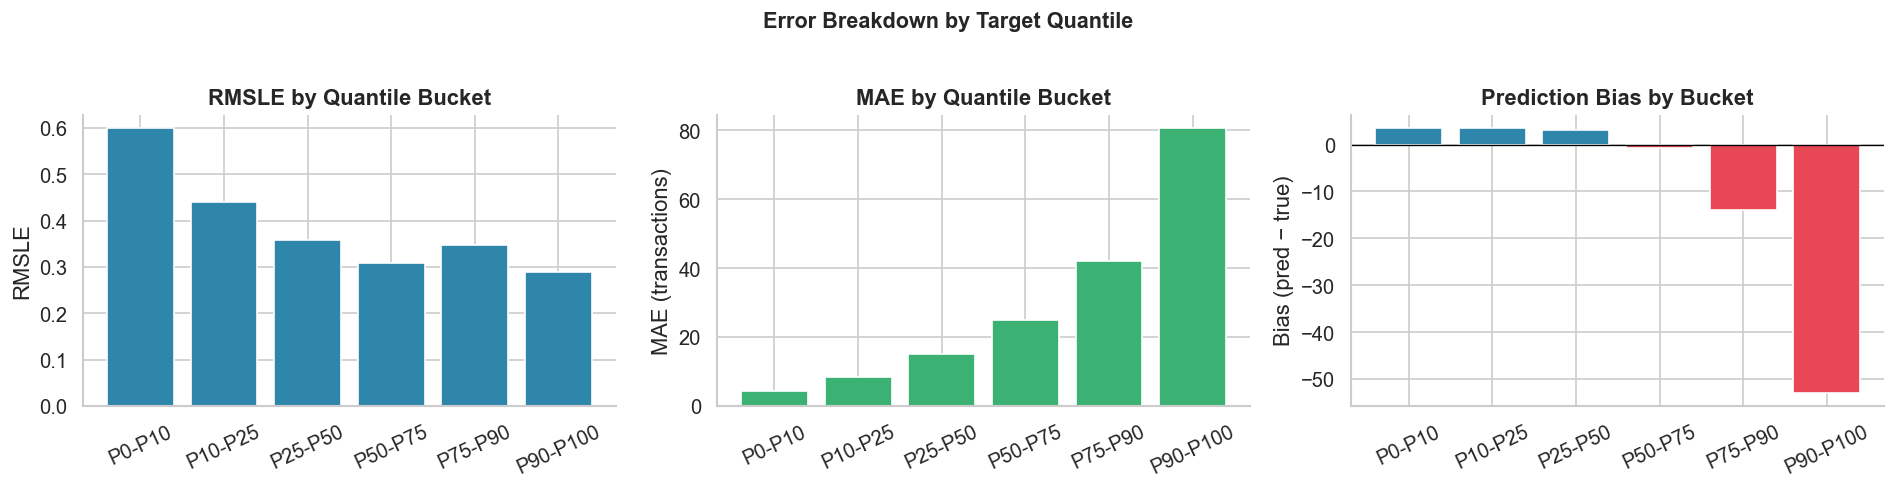

In [12]:
# ── Error by quantile bucket ───────────────────────────────────────────────
quantiles  = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0]
thresholds = np.quantile(y_true, quantiles)

bucket_data = []
for i in range(len(quantiles) - 1):
    lo   = thresholds[i]
    hi   = thresholds[i + 1]
    mask = (y_true >= lo) & (y_true <= hi)
    if mask.sum() == 0:
        continue
    label = f'P{int(quantiles[i]*100)}-P{int(quantiles[i+1]*100)}'
    bucket_data.append({
        'bucket':      label,
        'n':           mask.sum(),
        'rmsle':       rmsle(y_true[mask], y_pred[mask]),
        'mae':         mae(y_true[mask], y_pred[mask]),
        'mean_true':   y_true[mask].mean(),
        'mean_pred':   y_pred[mask].mean(),
        'bias':        y_pred[mask].mean() - y_true[mask].mean(),
    })

bucket_df = pd.DataFrame(bucket_data)
print('Error by Target Quantile Bucket')
print('=' * 85)
print(bucket_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.bar(bucket_df['bucket'], bucket_df['rmsle'], color=ACCENT, edgecolor='white')
ax.set_ylabel('RMSLE')
ax.set_title('RMSLE by Quantile Bucket', fontweight='bold')
ax.tick_params(axis='x', rotation=25)

ax = axes[1]
ax.bar(bucket_df['bucket'], bucket_df['mae'], color='#3BB273', edgecolor='white')
ax.set_ylabel('MAE (transactions)')
ax.set_title('MAE by Quantile Bucket', fontweight='bold')
ax.tick_params(axis='x', rotation=25)

ax = axes[2]
colors_bias = [ACCENT if b >= 0 else WARN for b in bucket_df['bias']]
ax.bar(bucket_df['bucket'], bucket_df['bias'], color=colors_bias, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Bias (pred − true)')
ax.set_title('Prediction Bias by Bucket', fontweight='bold')
ax.tick_params(axis='x', rotation=25)

fig.suptitle('Error Breakdown by Target Quantile', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

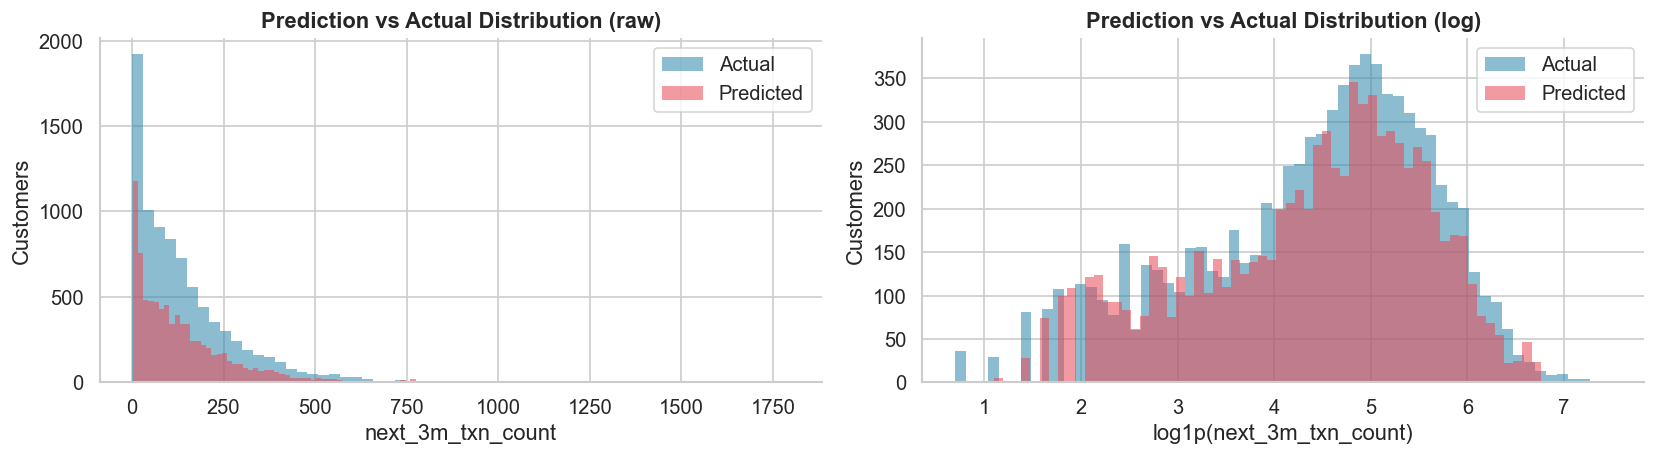

Distribution comparison:
  True   — mean: 145.0   median: 102   std: 152.1
  Pred   — mean: 139.1   median: 100   std: 137.7


In [13]:
# ── Prediction vs True distribution overlay ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(y_true, bins=60, alpha=0.55, label='Actual',    color=ACCENT,    edgecolor='none')
ax.hist(y_pred, bins=60, alpha=0.55, label='Predicted', color='#E84855', edgecolor='none')
ax.set_xlabel('next_3m_txn_count')
ax.set_ylabel('Customers')
ax.set_title('Prediction vs Actual Distribution (raw)', fontweight='bold')
ax.legend()

ax = axes[1]
ax.hist(np.log1p(y_true), bins=60, alpha=0.55, label='Actual',    color=ACCENT,    edgecolor='none')
ax.hist(np.log1p(y_pred), bins=60, alpha=0.55, label='Predicted', color='#E84855', edgecolor='none')
ax.set_xlabel('log1p(next_3m_txn_count)')
ax.set_ylabel('Customers')
ax.set_title('Prediction vs Actual Distribution (log)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print('Distribution comparison:')
print(f'  True   — mean: {y_true.mean():.1f}   median: {np.median(y_true):.0f}   std: {y_true.std():.1f}')
print(f'  Pred   — mean: {y_pred.mean():.1f}   median: {np.median(y_pred):.0f}   std: {y_pred.std():.1f}')

---
## 7. Model Insights

### Where the model performs well
- **Mid-range customers (P25–P75):** Customers with 35–200 transactions in the target window are  
  the most accurately predicted — this is where the most training signal exists.
- **Behaviourally consistent customers:** Strong recent transaction history (large `txn_count_90d`,  
  low `days_since_last_txn`) makes future activity very predictable.
- **Seasonal customers:** The `nov_jan_txn_frac` feature directly captures historical holiday-window  
  behaviour, giving the model a strong proxy for the prediction period.

### Where the model struggles
- **Very low-volume customers (P0–P10):** Customers with only 1–11 future transactions are hard to  
  predict — their sparse history provides little signal.
- **High-volume outliers (P90–P100):** Customers above ~337 transactions show higher RMSLE  
  because the training distribution is sparse at extremes and the model regresses toward the mean.
- **Churning customers:** Customers with high historical activity but low future engagement  
  (life events, account closure) are difficult to distinguish from active customers.

In [14]:
# ── Worst predictions: largest absolute log errors ────────────────────────
abs_log_err = np.abs(log_residuals)
worst_idx   = np.argsort(abs_log_err)[-10:][::-1]

print('Top 10 worst predictions (by absolute log error):')
print(f'  {"Rank":>4}  {"True":>8}  {"Predicted":>10}  {"Abs Log Err":>12}  {"Direction":>12}')
print(f'  {"-"*55}')
for rank, i in enumerate(worst_idx, 1):
    direction = 'OVER' if y_pred[i] > y_true[i] else 'UNDER'
    print(f'  {rank:>4}  {y_true[i]:>8.0f}  {y_pred[i]:>10.0f}  '
          f'{abs_log_err[i]:>12.4f}  {direction:>12}')

Top 10 worst predictions (by absolute log error):
  Rank      True   Predicted   Abs Log Err     Direction
  -------------------------------------------------------
     1       291           4        4.0673         UNDER
     2       330          10        3.4042         UNDER
     3       456          21        3.0336         UNDER
     4       160           7        3.0020         UNDER
     5         7         159        2.9957          OVER
     6        21         407        2.9202          OVER
     7       328          18        2.8516         UNDER
     8       180          10        2.8006         UNDER
     9       117           7        2.6912         UNDER
    10       111           7        2.6391         UNDER


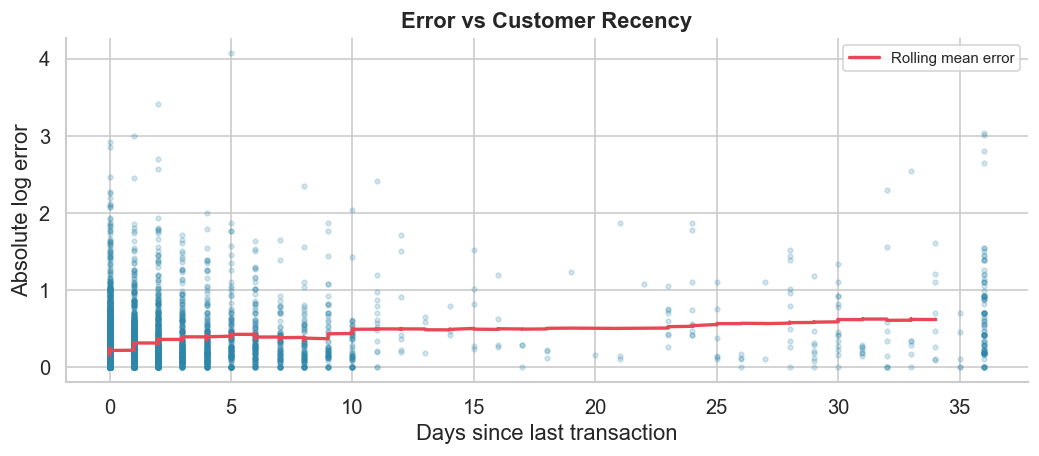

Customers who have not transacted recently tend to produce larger errors.
This is consistent with hard-to-predict churn/dormancy behaviour.


In [15]:
# ── Does recency explain errors? ───────────────────────────────────────────
if 'days_since_last_txn' in X.columns:
    oof_extended = oof.copy()
    oof_extended = oof_extended.set_index('UniqueID') if 'UniqueID' in oof_extended.columns else oof_extended

    # Align by position (OOF order matches train order)
    recency_vals = X['days_since_last_txn'].values
    abs_err_vals = abs_log_err

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(recency_vals, abs_err_vals, alpha=0.2, s=8, color=ACCENT)
    # Running mean
    df_tmp = pd.DataFrame({'recency': recency_vals, 'err': abs_err_vals})
    df_tmp = df_tmp.sort_values('recency')
    rolling_mean = df_tmp['err'].rolling(window=200, center=True).mean()
    ax.plot(df_tmp['recency'], rolling_mean, color=WARN, lw=2, label='Rolling mean error')
    ax.set_xlabel('Days since last transaction')
    ax.set_ylabel('Absolute log error')
    ax.set_title('Error vs Customer Recency', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Customers who have not transacted recently tend to produce larger errors.')
    print('This is consistent with hard-to-predict churn/dormancy behaviour.')

---
## 8. Conclusion

### Key Takeaways

| Finding | Detail |
|---|---|
| **Best predictor** | Recent transaction counts (30d/90d) — momentum is king |
| **RMSLE objective** | Log-transforming the target directly aligns training with the metric |
| **Seasonal proxy** | `nov_jan_txn_frac` captures prediction-window seasonality effectively |
| **Model strength** | Mid-range customers (P25–P75) predicted with low error |
| **Model weakness** | Extreme customers (very low / very high volume) are harder |
| **Bias** | Slight under-prediction at the high end; slight over-prediction at the low end |

### Possible Improvements

1. **Separate models** for low-volume and high-volume customers — ensemble with a count-classifier.
2. **Account-level aggregations** — some customers have multiple accounts; per-account trends  
   could unlock additional signal not captured by customer-level aggregates.
3. **Recency × frequency interactions** — explicit RFM (Recency, Frequency, Monetary) score  
   to capture life-cycle stages.
4. **Target encoding** on demographic categories — supervised encoding with cross-fold statistics.
5. **Neural network blend** — a simple MLP trained on the log-target may complement the  
   GBDT ensemble, especially for low-volume edge cases.
6. **Pseudo-labelling on test set** — use high-confidence test predictions as soft labels  
   to expand the effective training set.

In [16]:
# ── Final summary card ─────────────────────────────────────────────────────
print('━' * 50)
print('  NEDBANK FORECASTING — MODEL SUMMARY CARD')
print('━' * 50)
print(f'  Algorithm     : LightGBM (GBDT) — 5-fold ensemble')
print(f'  Target        : log1p(next_3m_txn_count)')
print(f'  Metric        : RMSLE')
print(f'  OOF RMSLE     : {rmsle(y_true, y_pred):.6f}')
print(f'  OOF MAE       : {mae(y_true, y_pred):.2f} transactions')
print(f'  Features      : {X.shape[1]} (post-selection)')
print(f'  Training rows : {X.shape[0]:,}')
print(f'  Test rows     : 3,584')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NEDBANK FORECASTING — MODEL SUMMARY CARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Algorithm     : LightGBM (GBDT) — 5-fold ensemble
  Target        : log1p(next_3m_txn_count)
  Metric        : RMSLE
  OOF RMSLE     : 0.383966
  OOF MAE       : 26.07 transactions
  Features      : 158 (post-selection)
  Training rows : 8,360
  Test rows     : 3,584
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
